# MECH5720 Lectures 2 & 3: images as data

| Section | What it shows |
| --- | --- |
| 1. What a raw image is | A monochrome raw as a picture then as numbers; a Bayer raw as numbers, then with the colour filter shown; a sub-lattice on its own; the demosaiced result. |
| 2. Raw vs uncompressed | "Raw" and "uncompressed" are different claims. A linear mosaic, a simulated ISP, the result written uncompressed and as low-quality JPEG, and the byte counts. |
| 3. Ways of looking at an image | Line profiles, histograms, spotting saturation, and a dark scene with a nonzero black level. |
| 4. Gamma stretch | Power-law stretching of a dim linear capture, and the transfer curves. |
| 5. Bit depth | A file with 16-bit samples is not a 16-bit image. Finding the real bit depth, and why digital gain adds no information. |
| 6. SNR estimation | Burst averaging vs one long exposure, and what an uncalibrated gain and black level do. |

All the `.raw` files are headerless: just the samples, row-major,
little-endian. The filename carries what you need to read it, e.g.
`darkscene_900x600_12bit_in_16.raw` is 900 columns by 600 rows of 16-bit
little-endian integers holding 12-bit data.

Python indexes from 0, and so do all the row/column numbers on the
figures. Where a demo pulls a patch out of a Bayer image, the top-left
corner must land on an even row and even column to sit on the R site of
the RGGB tile.

## Setup

Imports and the shared helpers.

In [1]:
%matplotlib inline
import os
import tempfile
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.ndimage import convolve

ASSETS = Path("assets/Lec2_3")   # run the notebook from the LectureCode/ folder

# Dark background, to match the lecture slides. The plots use yellow lines
# for the same reason.
plt.style.use("dark_background")
mpl.rcParams.update({
    "figure.figsize": (7.5, 5.5),
    "axes.grid": False,
    "image.interpolation": "nearest",
    "font.size": 10,
})
YEL = (1.0, 0.85, 0.15)


def read_raw(name, w, h, dtype):
    '''Headerless, row-major, little-endian raw file -> (h, w) array.'''
    path = Path(name)
    if not path.is_absolute():
        path = ASSETS / path
    dt = np.dtype(dtype).newbyteorder("<")
    a = np.fromfile(path, dtype=dt)
    if a.size != w * h:
        raise ValueError(f"{path}: got {a.size} samples, expected {w * h}")
    return a.reshape(h, w)


def imagesc(ax, img, clim=None, cmap="gray"):
    '''imagesc + axis image. 2D uses a colormap; HxWx3 is shown as colour.'''
    img = np.asarray(img)
    if img.ndim == 3:
        h = ax.imshow(np.clip(img, 0, 1), aspect="equal")
    else:
        vmin, vmax = (None, None) if clim is None else clim
        h = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal")
    return h


def stem(ax, x, y, color=YEL, markersize=3, marker=True, label=None):
    c = ax.stem(x, y, linefmt="-", markerfmt="o", basefmt=" ", label=label)
    c.stemlines.set(color=color, linewidth=1.0)
    if marker:
        c.markerline.set(color=color, markerfacecolor=color, markersize=markersize)
    else:
        c.markerline.set_visible(False)
    return c


def show_numbers(ax, patch, tint=None, r0=0, c0=0, maxval=255):
    '''Draw a small patch as coloured cells with the pixel value written in.'''
    patch = np.asarray(patch)
    m, n = patch.shape
    v = patch.astype(float) / maxval
    img = np.repeat(v[:, :, None], 3, axis=2) if tint is None \
        else np.asarray(tint, float) * v[:, :, None]
    ax.imshow(np.clip(img, 0, 1), aspect="equal")
    for i in range(m):
        for j in range(n):
            lum = 0.3 * img[i, j, 0] + 0.6 * img[i, j, 1] + 0.1 * img[i, j, 2]
            ax.text(j, i, f"{patch[i, j]:d}", color="k" if lum > 0.45 else "w",
                    ha="center", va="center", fontsize=11, fontweight="bold")
    ax.set_xticks(range(n), [str(c) for c in range(c0, c0 + n)])
    ax.set_yticks(range(m), [str(r) for r in range(r0, r0 + m)])
    ax.set_xlabel("column"); ax.set_ylabel("row")


def _cfa_offsets(pattern):
    return {
        "rggb": ((0, 0), (0, 1), (1, 0), (1, 1)),
        "bggr": ((1, 1), (0, 1), (1, 0), (0, 0)),
        "grbg": ((0, 1), (0, 0), (1, 1), (1, 0)),
        "gbrg": ((1, 0), (0, 0), (1, 1), (0, 1)),
    }[pattern.lower()]


def cfa_masks(h, w, pattern="rggb"):
    '''Boolean R, G, B site masks for an h-by-w sensor.'''
    (rr, rc), (g1r, g1c), (g2r, g2c), (br, bc) = _cfa_offsets(pattern)
    R = np.zeros((h, w), bool); G = np.zeros((h, w), bool); B = np.zeros((h, w), bool)
    R[rr::2, rc::2] = True
    G[g1r::2, g1c::2] = True
    G[g2r::2, g2c::2] = True
    B[br::2, bc::2] = True
    return R, G, B


def cfa_mask(h, w, pattern="rggb"):
    '''Unit-scale RGB colour of the filter sitting over each pixel.'''
    R, G, B = cfa_masks(h, w, pattern)
    return np.stack([R, G, B], axis=-1).astype(float)


# Malvar-He-Cutler gradient-corrected linear interpolation: four 5x5 kernels
# applied to the mosaic itself.
_GR_GB = np.array([[0, 0, -1, 0, 0], [0, 0, 2, 0, 0], [-1, 2, 4, 2, -1],
                   [0, 0, 2, 0, 0], [0, 0, -1, 0, 0]], float) / 8.0
_Rg_RB = np.array([[0, 0, 0.5, 0, 0], [0, -1, 0, -1, 0], [-1, 4, 5, 4, -1],
                   [0, -1, 0, -1, 0], [0, 0, 0.5, 0, 0]], float) / 8.0
_Rg_BR = _Rg_RB.T
_Rb_BB = np.array([[0, 0, -1.5, 0, 0], [0, 2, 0, 2, 0], [-1.5, 0, 6, 0, -1.5],
                   [0, 2, 0, 2, 0], [0, 0, -1.5, 0, 0]], float) / 8.0


def demosaic(bayer, pattern="rggb"):
    '''Malvar-He-Cutler demosaic. Returns HxWx3 in the input's dtype range.'''
    a = np.asarray(bayer)
    dt = a.dtype
    cfa = a.astype(np.float64)
    h, w = cfa.shape
    Rm, Gm, Bm = cfa_masks(h, w, pattern)
    R = cfa * Rm; G = cfa * Gm; B = cfa * Bm
    R_r = np.tile(Rm.any(axis=1)[:, None], (1, w))
    R_c = np.tile(Rm.any(axis=0)[None, :], (h, 1))
    B_r = np.tile(Bm.any(axis=1)[:, None], (1, w))
    B_c = np.tile(Bm.any(axis=0)[None, :], (h, 1))
    conv = lambda k: convolve(cfa, k, mode="mirror")
    G = np.where(Rm | Bm, conv(_GR_GB), G)
    RB_gRB = conv(_Rg_RB); RB_gBR = conv(_Rg_BR); RB_diag = conv(_Rb_BB)
    R = np.where(R_r & B_c, RB_gRB, R)
    R = np.where(B_r & R_c, RB_gBR, R)
    B = np.where(B_r & R_c, RB_gRB, B)
    B = np.where(R_r & B_c, RB_gBR, B)
    R = np.where(B_r & B_c, RB_diag, R)
    B = np.where(R_r & R_c, RB_diag, B)
    rgb = np.stack([R, G, B], axis=-1)
    if np.issubdtype(dt, np.integer):
        info = np.iinfo(dt)
        return np.clip(np.round(rgb), info.min, info.max).astype(dt)
    return rgb

## 1. What a raw image actually is

A raw file is one number per pixel, row-major, no header. For a
monochrome sensor that number is a brightness. For a colour sensor there
is a colour filter array (CFA) glued over the pixels, most commonly the
Bayer RGGB tile, so each pixel measures only red, only green, or only
blue and the missing two are interpolated later (demosaicing).

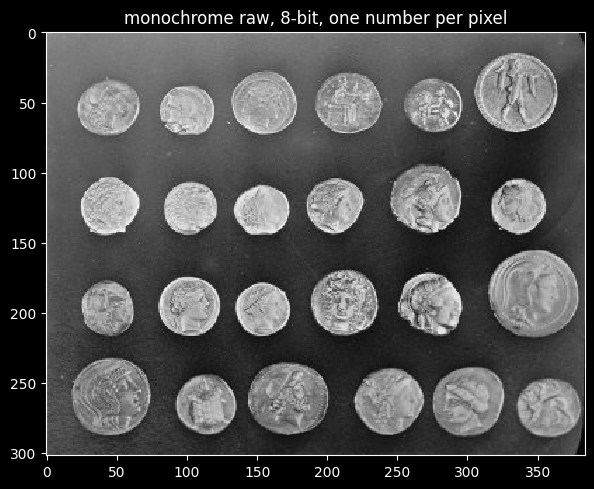

In [2]:
mono = read_raw("mono_384x302_8bit.raw", 384, 302, np.uint8)
bayer = read_raw("bayer_512x512_rggb_8bit.raw", 512, 512, np.uint8)
pattern = "rggb"

fig, ax = plt.subplots()
imagesc(ax, mono, [0, 255])
ax.set_title("monochrome raw, 8-bit, one number per pixel");

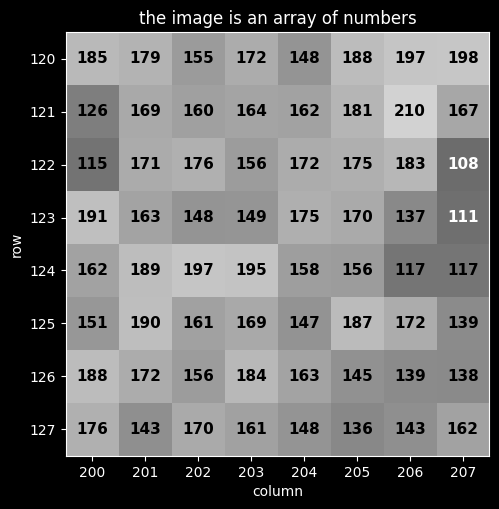

In [3]:
# a small patch across an edge, shown as the numbers it really is
r0, c0, n = 120, 200, 8
fig, ax = plt.subplots()
show_numbers(ax, mono[r0:r0 + n, c0:c0 + n], None, r0, c0)
ax.set_title("the image is an array of numbers");

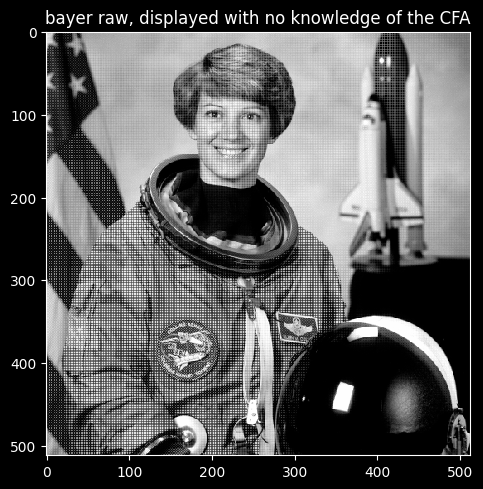

In [4]:
fig, ax = plt.subplots()
imagesc(ax, bayer, [0, 255])
ax.set_title("bayer raw, displayed with no knowledge of the CFA");

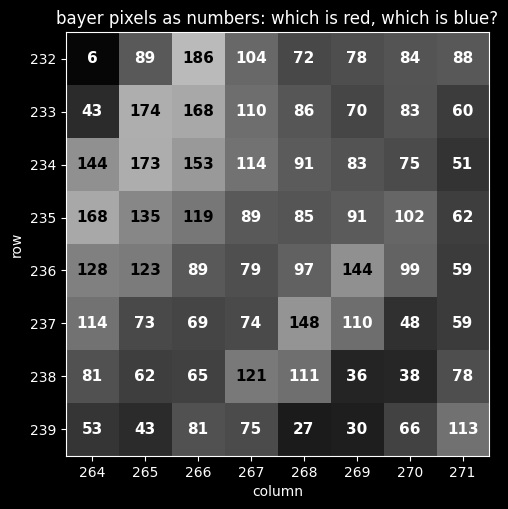

In [5]:
# Bayer pixels as numbers. Keep rb, cb both even so the top-left cell lands
# on an R site of the RGGB tile.
rb, cb, m = 232, 264, 8
bpatch = bayer[rb:rb + m, cb:cb + m]

fig, ax = plt.subplots()
show_numbers(ax, bpatch, None, rb, cb)
ax.set_title("bayer pixels as numbers: which is red, which is blue?");

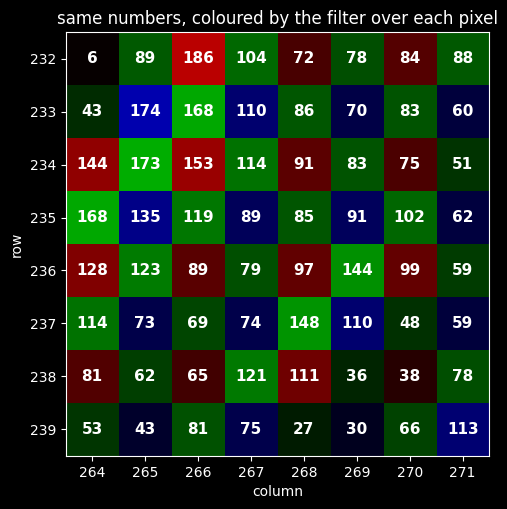

In [6]:
# the same numbers, now coloured by the filter over each pixel
cfa = cfa_mask(bayer.shape[0], bayer.shape[1], pattern)

fig, ax = plt.subplots()
show_numbers(ax, bpatch, cfa[rb:rb + m, cb:cb + m, :], rb, cb)
ax.set_title("same numbers, coloured by the filter over each pixel");

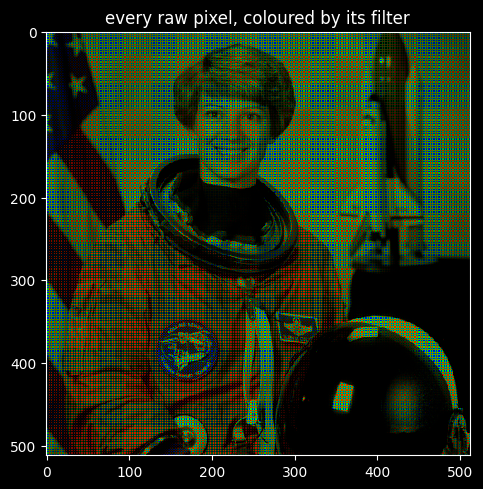

In [7]:
# every raw pixel, coloured by its filter: 2/3 of each channel is missing
bayerRGB = cfa * bayer[:, :, None].astype(float) / 255

fig, ax = plt.subplots()
imagesc(ax, bayerRGB)
ax.set_title("every raw pixel, coloured by its filter");

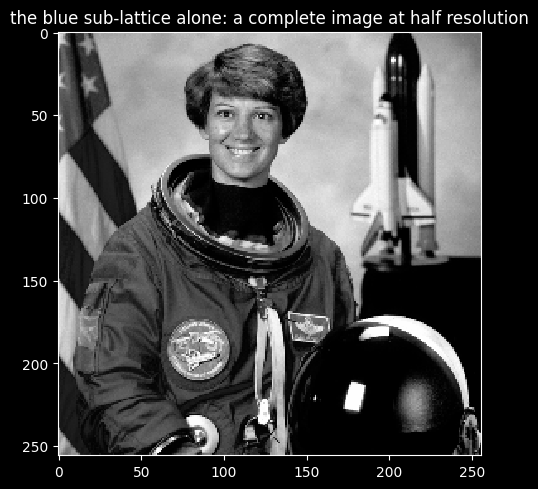

In [8]:
# sub-lattice: RGGB, so blue sits at odd row, odd column (0-based)
blue = bayer[1::2, 1::2]

fig, ax = plt.subplots()
imagesc(ax, blue, [0, 255])
ax.set_title("the blue sub-lattice alone: a complete image at half resolution");

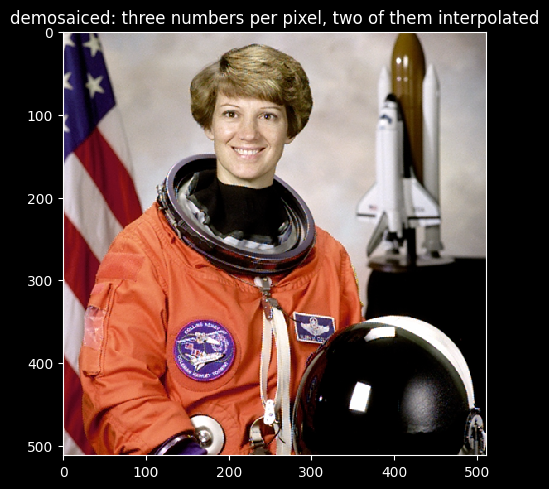

In [9]:
rgb = demosaic(bayer, pattern)

fig, ax = plt.subplots()
imagesc(ax, rgb.astype(float) / 255)
ax.set_title("demosaiced: three numbers per pixel, two of them interpolated");

## 2. Raw vs uncompressed

- **raw**: sensor samples, one number per pixel, linear, unprocessed
- **uncompressed**: every pixel stored exactly, but processed first
- **compressed**: pixels approximated to save bytes

The middle one is uncompressed but not raw. Below: a linear 12-bit
mosaic, a simulated in-camera ISP (white balance, demosaic, gamma), then
the ISP output written with every pixel stored exactly and again as a
low-quality JPEG, and the byte counts of all three.

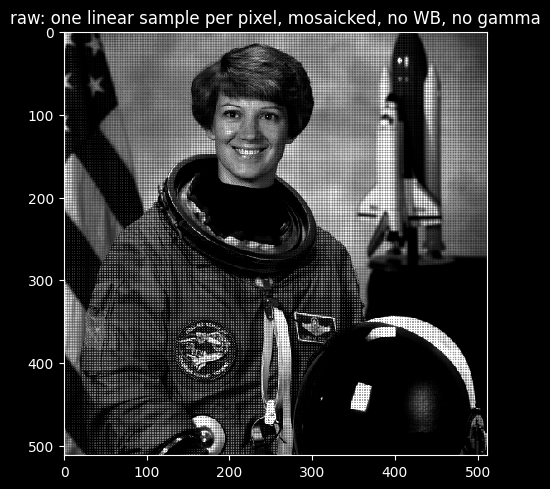

In [10]:
rawFile = "bayer_linear_512x512_rggb_12in16bit.raw"
W, H, pattern, maxVal = 512, 512, "rggb", 4095    # 12 bits in a 16-bit container
wbGains = (0.65, 1.0, 1.25)                        # illuminant cast in the capture

bayer = read_raw(rawFile, W, H, np.uint16)

fig, ax = plt.subplots()
imagesc(ax, bayer, [0, maxVal])
ax.set_title("raw: one linear sample per pixel, mosaicked, no WB, no gamma");

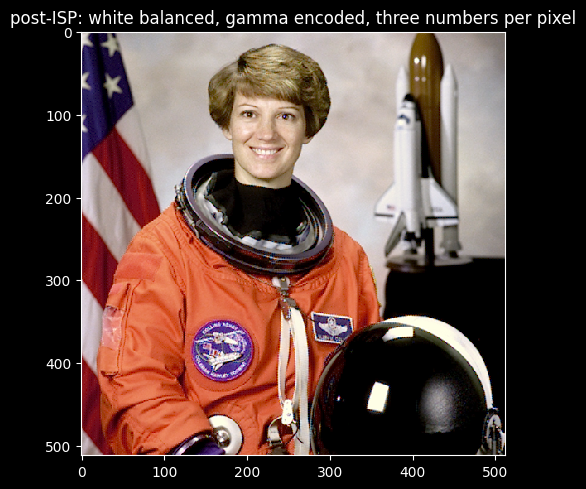

In [11]:
# simulate an on-camera ISP: white balance, demosaic, gamma
wb = bayer.astype(float) / maxVal
wb[0::2, 0::2] /= wbGains[0]      # R sites
wb[1::2, 1::2] /= wbGains[2]      # B sites
wb = (np.minimum(wb, 1) * 65535).astype(np.uint16)

rgbLin = demosaic(wb, pattern).astype(float) / 65535
isp = (255 * rgbLin ** (1 / 2.2)).astype(np.uint8)

fig, ax = plt.subplots()
imagesc(ax, isp.astype(float) / 255)
ax.set_title("post-ISP: white balanced, gamma encoded, three numbers per pixel");


file                           kB    x raw
raw (12-bit mosaic)         512.0     1.00
uncompressed RGB            768.0     1.50
JPEG q8                      10.3     0.02


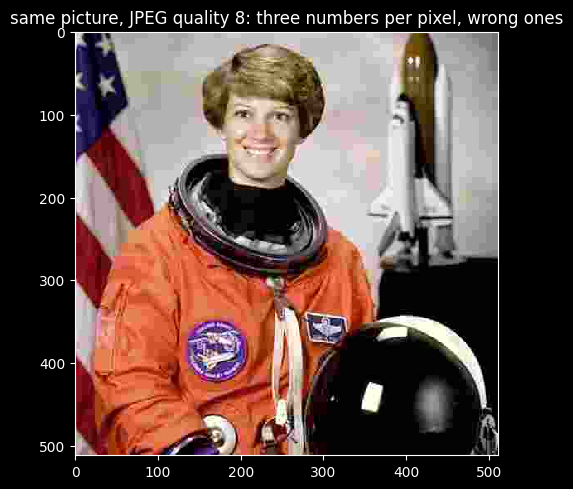

In [12]:
# write the ISP output uncompressed and as JPEG q8, then compare bytes
outdir = Path(tempfile.mkdtemp(prefix="lec23_"))
ispFile = outdir / "isp_512x512_rgb_8bit.raw"
jpegFile = outdir / "isp_q8.jpg"

isp.tofile(ispFile)                                  # interleaved RGB, row-major
Image.fromarray(isp).save(jpegFile, quality=8)
jpg = np.asarray(Image.open(jpegFile))

fig, ax = plt.subplots()
imagesc(ax, jpg.astype(float) / 255)
ax.set_title("same picture, JPEG quality 8: three numbers per pixel, wrong ones")

files = [ASSETS / rawFile, ispFile, jpegFile]
names = ["raw (12-bit mosaic)", "uncompressed RGB", "JPEG q8"]
byts = [os.path.getsize(f) for f in files]
print(f"\n{'file':<22} {'kB':>10} {'x raw':>8}")
for name, b in zip(names, byts):
    print(f"{name:<22} {b / 1024:>10.1f} {b / byts[0]:>8.2f}")

## 3. Ways of looking at an image beyond displaying it

### Line profiles

A row or column of an image is a 1D signal. Plotting it makes structure
measurable: coins become plateaus, a flat field reveals vignetting the
eye barely notices.

In [13]:
coins = read_raw("coins_384x302_8bit.raw", 384, 302, np.uint8)
flat = read_raw("flatfield_640x480_8bit.raw", 640, 480, np.uint8)
sat = read_raw("saturated_512x512_8bit.raw", 512, 512, np.uint8)
dark = read_raw("darkscene_900x600_12bit_in_16.raw", 900, 600, np.uint16)
coinH, coinW = coins.shape
flatH, flatW = flat.shape
satH, satW = sat.shape
darkH, darkW = dark.shape

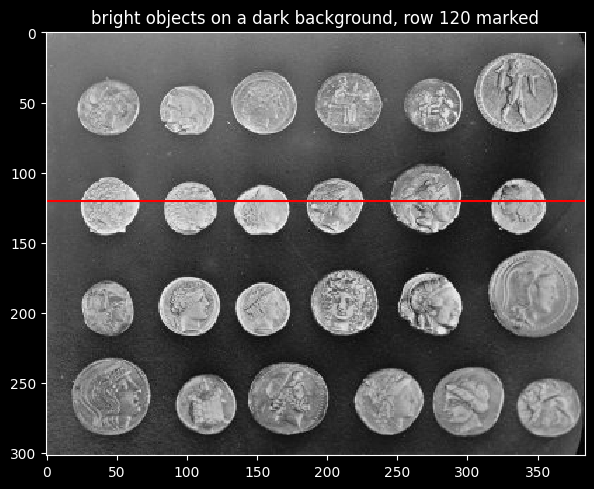

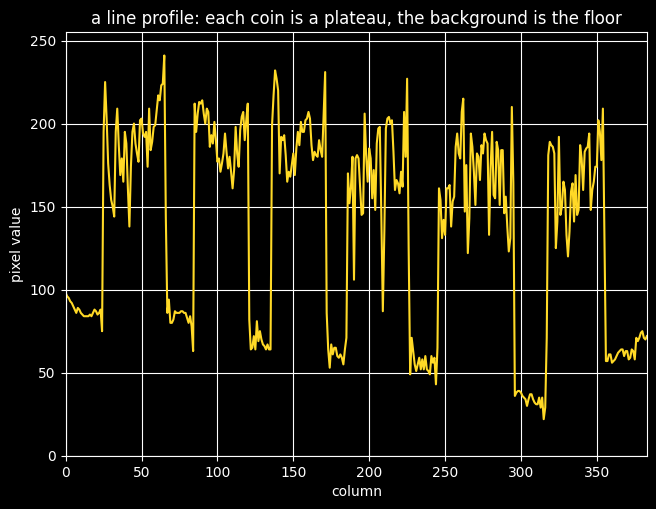

In [14]:
rowIdx = 120

fig, ax = plt.subplots()
imagesc(ax, coins, [0, 255])
ax.plot([0, coinW - 1], [rowIdx, rowIdx], "r-", linewidth=1.5)
ax.set_title(f"bright objects on a dark background, row {rowIdx} marked")

fig, ax = plt.subplots()
ax.plot(coins[rowIdx, :].astype(float), "-", color=YEL)
ax.set_xlim(0, coinW - 1); ax.set_ylim(0, 255)
ax.set_xlabel("column"); ax.set_ylabel("pixel value"); ax.grid(True)
ax.set_title("a line profile: each coin is a plateau, the background is the floor");

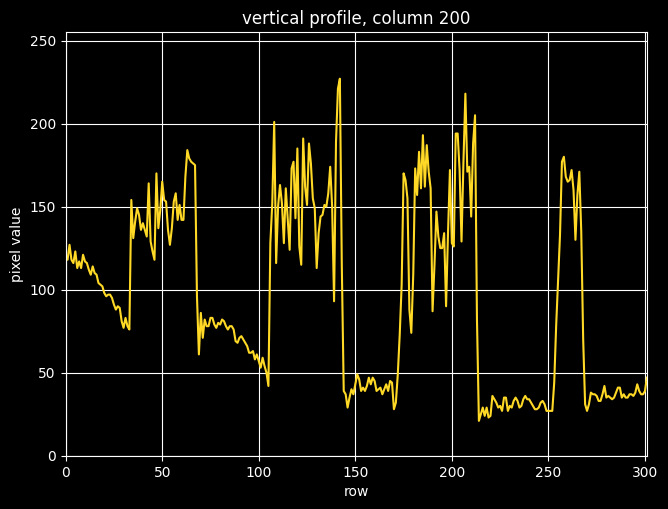

In [15]:
colIdx = 200

fig, ax = plt.subplots()
ax.plot(coins[:, colIdx].astype(float), "-", color=YEL)
ax.set_xlim(0, coinH - 1); ax.set_ylim(0, 255)
ax.set_xlabel("row"); ax.set_ylabel("pixel value"); ax.grid(True)
ax.set_title(f"vertical profile, column {colIdx}");

Text(0.5, 1.0, 'vignetting: edges are 41% of the centre')

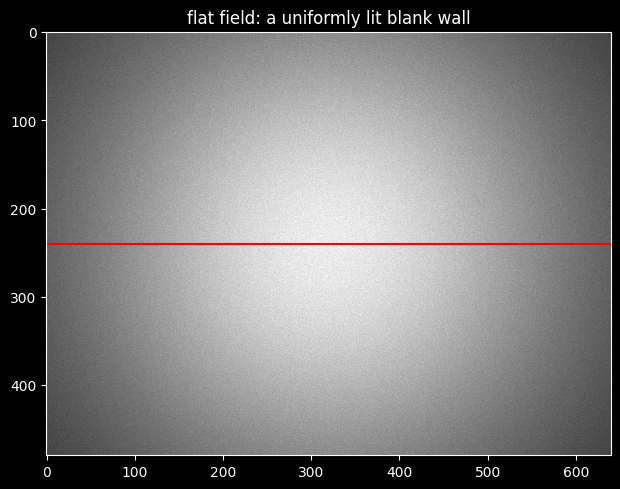

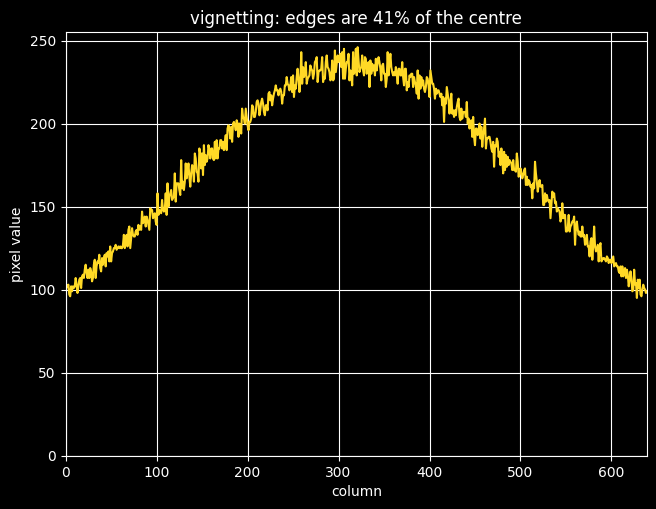

In [16]:
midRow = round(flatH / 2)
fprofile = flat[midRow, :].astype(float)
edgeFrac = 100 * np.mean(np.r_[fprofile[:5], fprofile[-5:]]) / fprofile.max()

fig, ax = plt.subplots()
imagesc(ax, flat, [0, 255])
ax.plot([0, flatW - 1], [midRow, midRow], "r-", linewidth=1.5)
ax.set_title("flat field: a uniformly lit blank wall")

fig, ax = plt.subplots()
ax.plot(fprofile, "-", color=YEL)
ax.set_xlim(0, flatW - 1); ax.set_ylim(0, 255)
ax.set_xlabel("column"); ax.set_ylabel("pixel value"); ax.grid(True)
ax.set_title(f"vignetting: edges are {edgeFrac:.0f}% of the centre")

# For an arbitrary path, not just a row or column, sample with
#   scipy.ndimage.map_coordinates(flat, [rr, cc], order=1)
# where rr, cc are linspace arrays of row and column coordinates.

### Histograms

The histogram shows the populations in the image: scene content, noise, clipping.

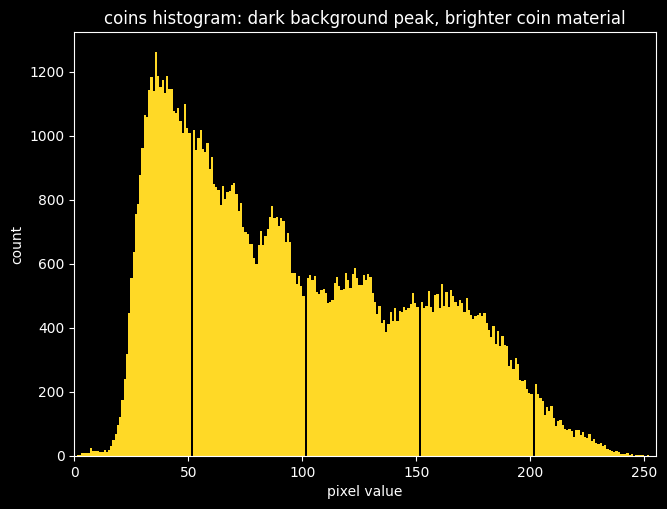

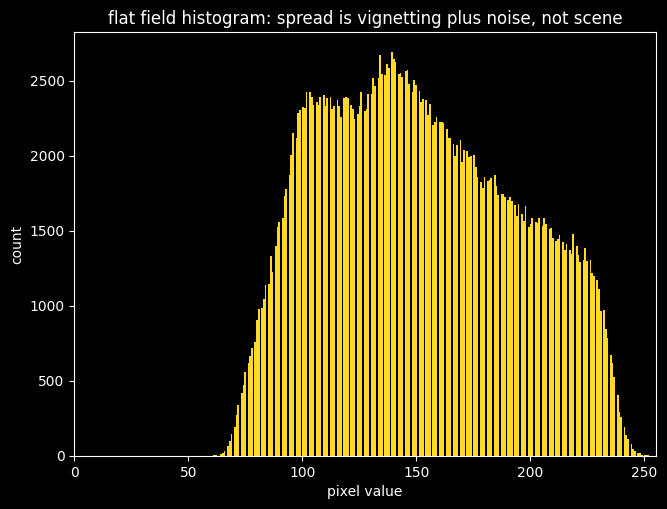

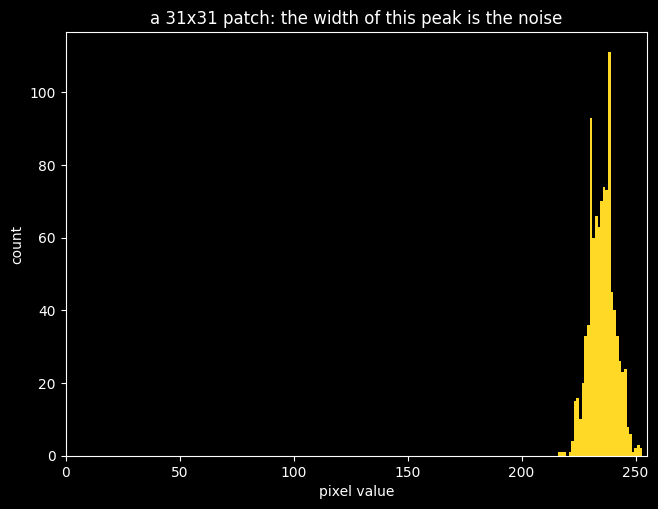

In [17]:
fig, ax = plt.subplots()
ax.hist(coins.ravel().astype(float), 256, color=YEL)
ax.set_xlim(0, 255); ax.set_xlabel("pixel value"); ax.set_ylabel("count")
ax.set_title("coins histogram: dark background peak, brighter coin material")

fig, ax = plt.subplots()
ax.hist(flat.ravel().astype(float), 256, color=YEL)
ax.set_xlim(0, 255); ax.set_xlabel("pixel value"); ax.set_ylabel("count")
ax.set_title("flat field histogram: spread is vignetting plus noise, not scene")

midCol = round(flatW / 2)
patch = flat[midRow - 15:midRow + 16, midCol - 15:midCol + 16]
fig, ax = plt.subplots()
ax.hist(patch.ravel().astype(float), 32, color=YEL)
ax.set_xlim(0, 255); ax.set_xlabel("pixel value"); ax.set_ylabel("count")
ax.set_title("a 31x31 patch: the width of this peak is the noise");

### Saturation

Clipped is not the same as bright: a spike piled up at the top of the range, and dead-flat profiles.

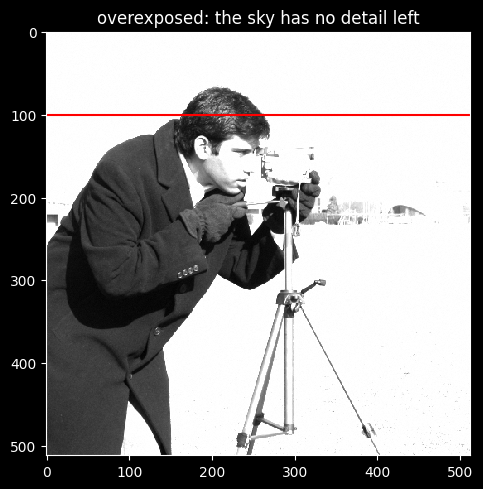

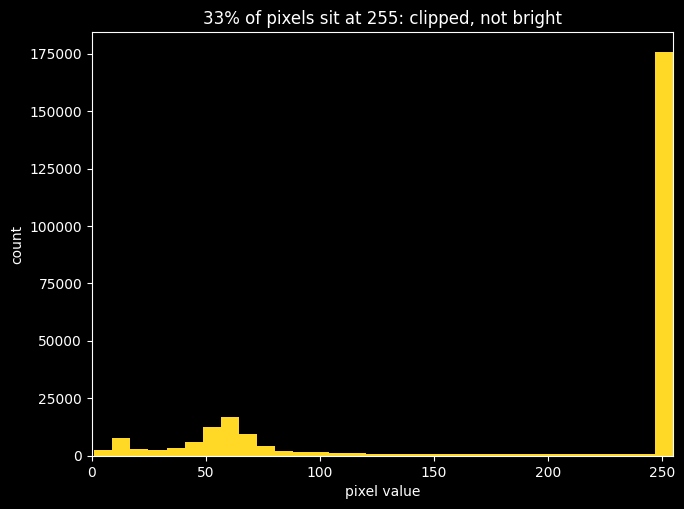

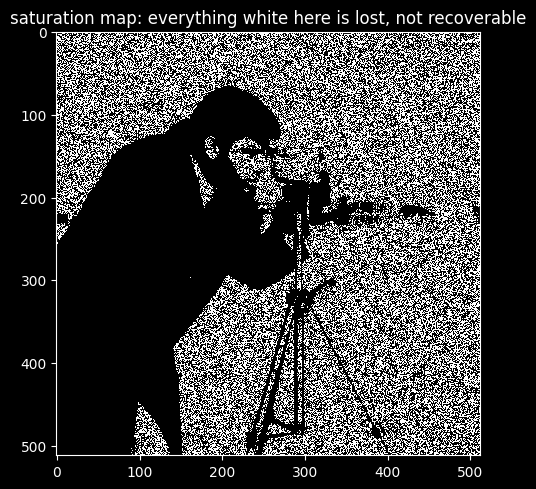

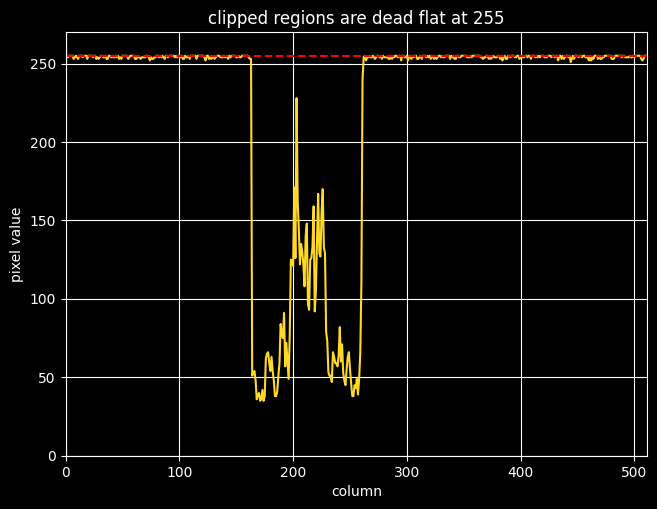

In [18]:
satRow = 100
clipped = 100 * np.mean(sat == 255)

fig, ax = plt.subplots()
imagesc(ax, sat, [0, 255])
ax.plot([0, satW - 1], [satRow, satRow], "r-", linewidth=1.5)
ax.set_title("overexposed: the sky has no detail left")

fig, ax = plt.subplots()
ax.hist(sat.ravel().astype(float), 32, color=YEL)
ax.set_xlim(0, 255); ax.set_xlabel("pixel value"); ax.set_ylabel("count")
ax.set_title(f"{clipped:.0f}% of pixels sit at 255: clipped, not bright")

fig, ax = plt.subplots()
imagesc(ax, (sat == 255).astype(float), [0, 1])
ax.set_title("saturation map: everything white here is lost, not recoverable")

fig, ax = plt.subplots()
ax.plot(sat[satRow, :].astype(float), "-", color=YEL)
ax.plot([0, satW - 1], [255, 255], "r--")
ax.set_xlim(0, satW - 1); ax.set_ylim(0, 270)
ax.set_xlabel("column"); ax.set_ylabel("pixel value"); ax.grid(True)
ax.set_title("clipped regions are dead flat at 255");

### A dark scene with a nonzero black level

The sensor has a pedestal: an all-dark frame does not read zero. Estimating it
from the median here is rough (it runs high, because any real background glow
is included); the proper way is a capped-lens dark frame or the sensor's
optical-black pixels. Subtracting it first is what makes the numbers
proportional to light.

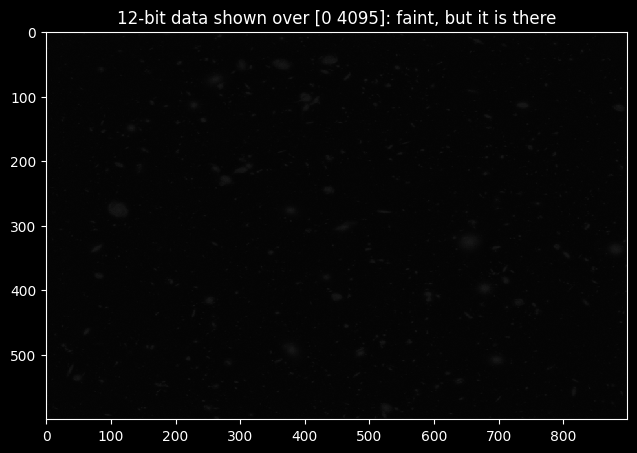

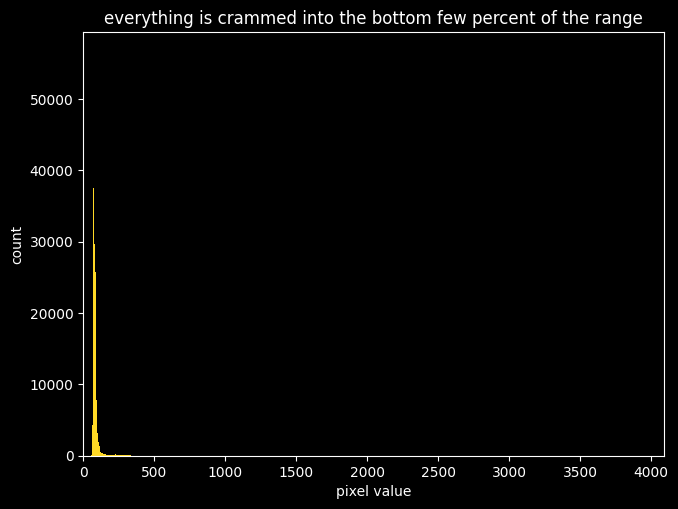

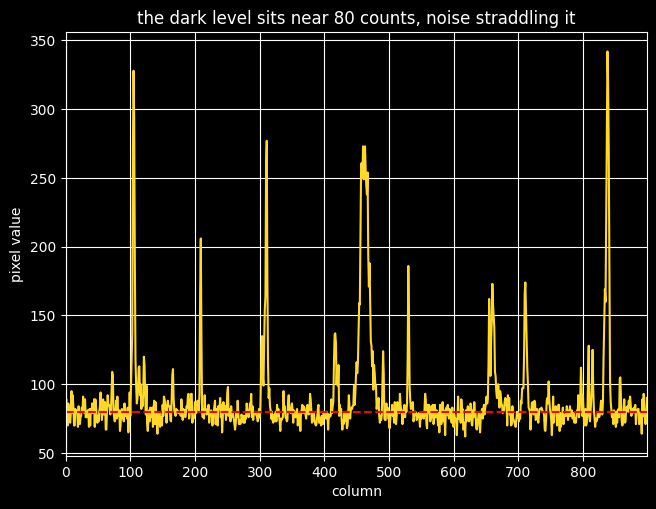

In [19]:
fig, ax = plt.subplots()
imagesc(ax, dark, [0, 4095])
ax.set_title("12-bit data shown over [0 4095]: faint, but it is there")

fig, ax = plt.subplots()
ax.hist(dark.ravel().astype(float), 256, color=YEL)
ax.set_xlim(0, 4095); ax.set_xlabel("pixel value"); ax.set_ylabel("count")
ax.set_title("everything is crammed into the bottom few percent of the range")

blackLevel = np.median(dark.astype(float))
darkRow = 300
fig, ax = plt.subplots()
ax.plot(dark[darkRow, :].astype(float), "-", color=YEL)
ax.plot([0, darkW - 1], [blackLevel, blackLevel], "r--")
ax.set_xlim(0, darkW - 1)
ax.set_xlabel("column"); ax.set_ylabel("pixel value"); ax.grid(True)
ax.set_title(f"the dark level sits near {blackLevel:.0f} counts, noise straddling it");

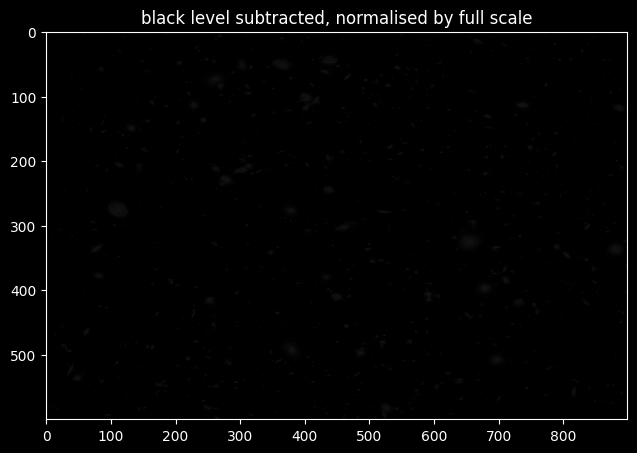

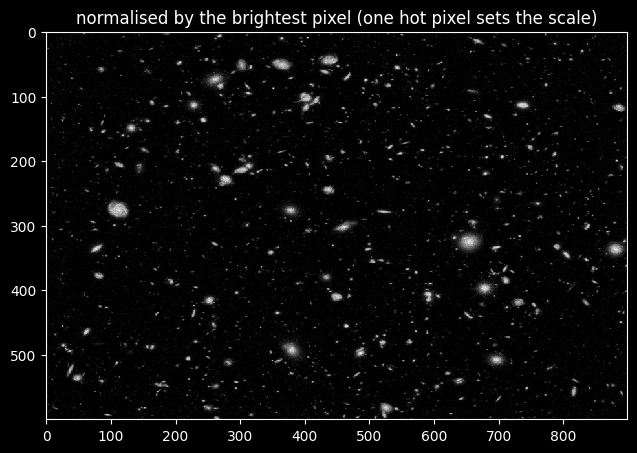

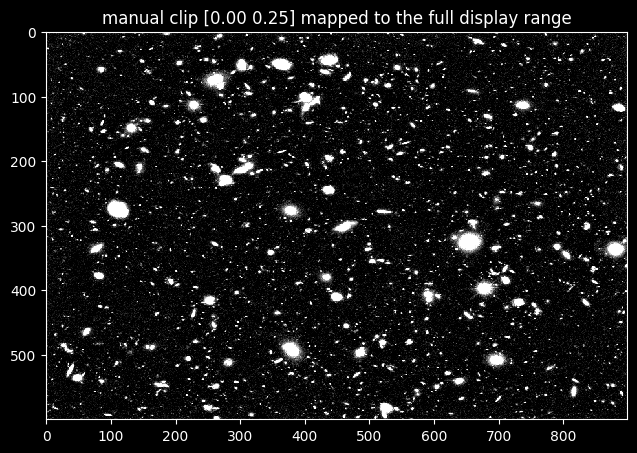

In [20]:
# four ways of displaying the same dark image
d = np.maximum(dark.astype(float) - blackLevel, 0) / 4095   # subtract, normalise by full scale
dn = d / d.max()                                            # normalise by the data
lo, hi = 0.00, 0.25
dc = np.clip((dn - lo) / (hi - lo), 0, 1)                   # manual percentile clip

for im, ttl in [(d, "black level subtracted, normalised by full scale"),
                (dn, "normalised by the brightest pixel (one hot pixel sets the scale)"),
                (dc, f"manual clip [{lo:.2f} {hi:.2f}] mapped to the full display range")]:
    fig, ax = plt.subplots()
    imagesc(ax, im, [0, 1])
    ax.set_title(ttl)

## 4. Gamma stretch: making a dim linear capture look right

Power-law stretching compresses the bright end and expands the dark end,
throwing nothing away (unlike clipping). It needs a scene with continuous
tone; something bimodal has nothing to redistribute. This is a night
launch pad: bright vehicle, gantry towers and ground haze just above the
noise floor. Peak signal is about 280 counts out of 4095, linear, with a
black level of 64.

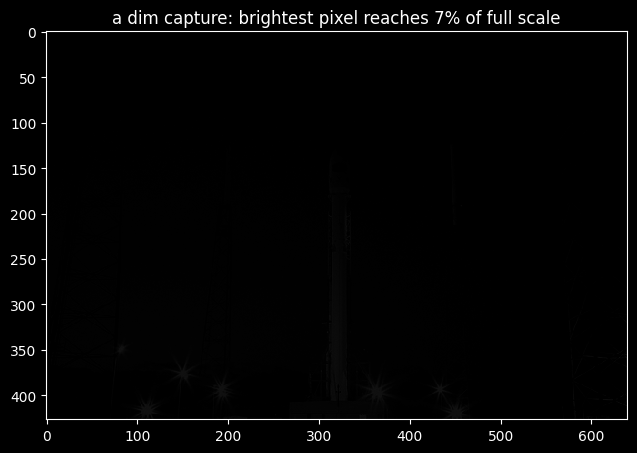

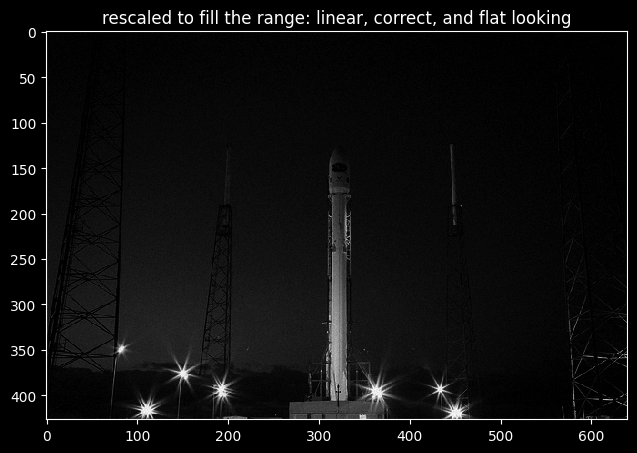

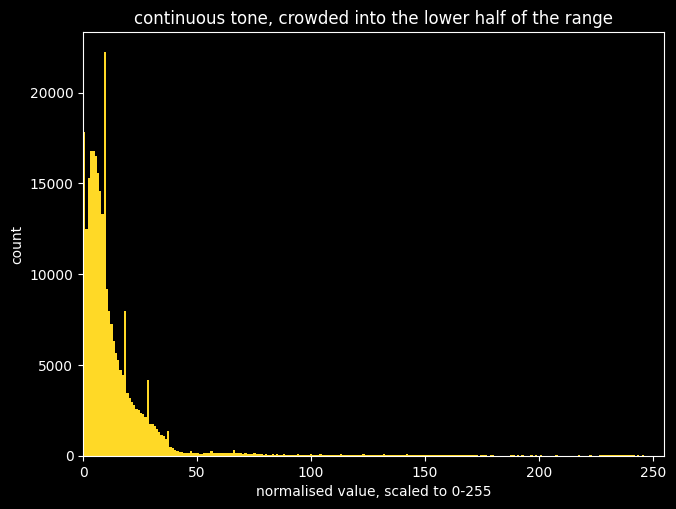

In [21]:
low = read_raw("rocket_640x427_12bit_in_16.raw", 640, 427, np.uint16)
lowLevel, maxCode = 64, 4095
l = np.maximum(low.astype(float) - lowLevel, 0)
ln = l / l.max()                                   # exposure fixed, tone curve not

fig, ax = plt.subplots()
imagesc(ax, l / maxCode, [0, 1])
ax.set_title(f"a dim capture: brightest pixel reaches {100 * l.max() / maxCode:.0f}% of full scale")

fig, ax = plt.subplots()
imagesc(ax, ln, [0, 1])
ax.set_title("rescaled to fill the range: linear, correct, and flat looking")

fig, ax = plt.subplots()
ax.hist(ln.ravel() * 255, 256, color=YEL)
ax.set_xlim(0, 255); ax.set_xlabel("normalised value, scaled to 0-255"); ax.set_ylabel("count")
ax.set_title("continuous tone, crowded into the lower half of the range");

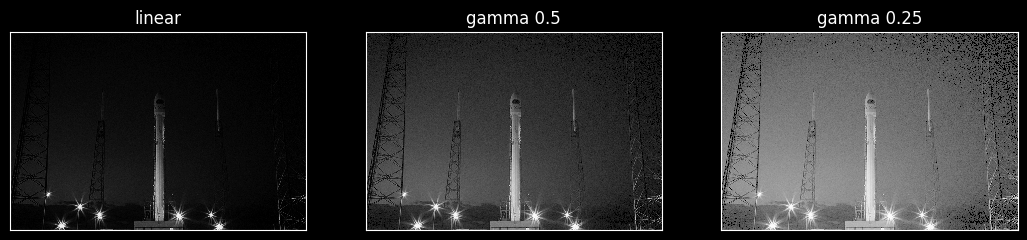

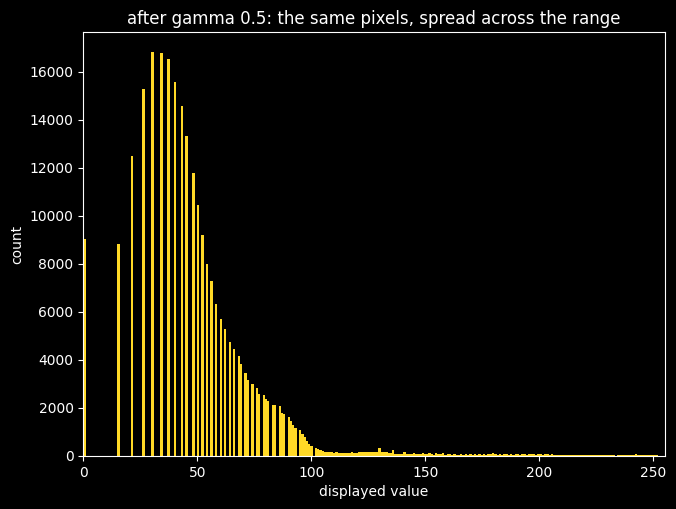

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (im, ttl) in zip(axes, [(ln, "linear"), (ln ** 0.5, "gamma 0.5"),
                                 (ln ** 0.25, "gamma 0.25")]):
    imagesc(ax, im, [0, 1]); ax.set_title(ttl); ax.set_xticks([]); ax.set_yticks([])

fig, ax = plt.subplots()
ax.hist((ln ** 0.5).ravel() * 255, 256, color=YEL)
ax.set_xlim(0, 255); ax.set_xlabel("displayed value"); ax.set_ylabel("count")
ax.set_title("after gamma 0.5: the same pixels, spread across the range");

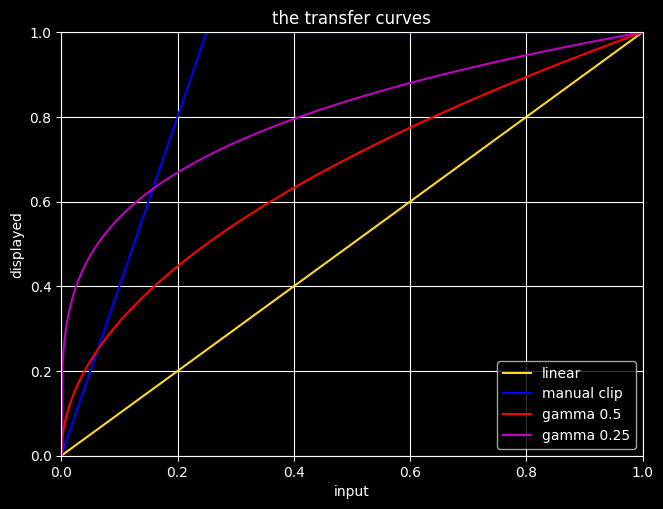

In [23]:
# the transfer curves: what each display choice does to the numbers
lo, hi = 0.00, 0.25
x = np.linspace(0, 1, 512)

fig, ax = plt.subplots()
ax.plot(x, x, "-", color=YEL, label="linear")
ax.plot(x, np.clip((x - lo) / (hi - lo), 0, 1), "b-", label="manual clip")
ax.plot(x, x ** 0.5, "r-", label="gamma 0.5")
ax.plot(x, x ** 0.25, "m-", label="gamma 0.25")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("input"); ax.set_ylabel("displayed")
ax.legend(loc="lower right"); ax.grid(True)
ax.set_title("the transfer curves");

## 5. Bit depth: a file with 16-bit samples is not a 16-bit image

This one came off a 10-bit ADC and was left-justified into a 16-bit
container, so it fills the full 0..65535 range using only 1024 distinct
codes. A coarse histogram hides that; one bin per code, zoomed in, shows
the comb. Digital gain rescales the codes, it does not create new ones.

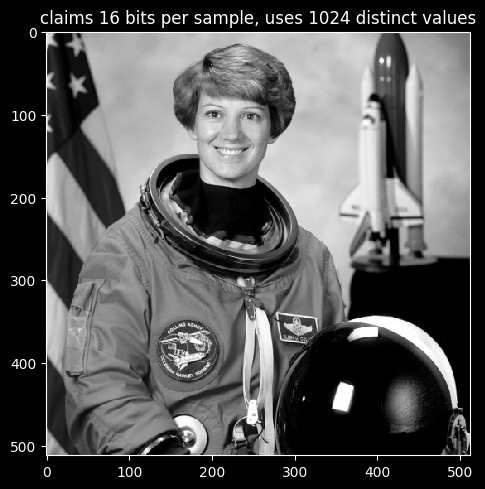

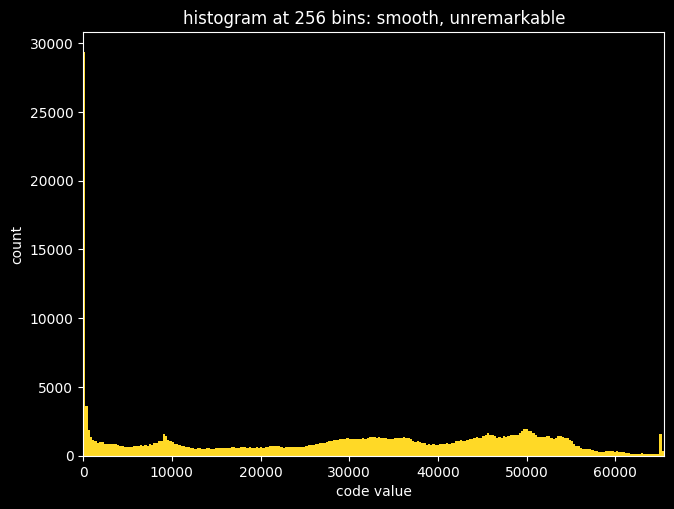

In [24]:
img = read_raw("mono_10in16bit_512x512.raw", 512, 512, np.uint16)
gain = 2.5
x = img.ravel().astype(float)
nLevels = np.unique(img).size

fig, ax = plt.subplots()
imagesc(ax, img, [0, 65535])
ax.set_title(f"claims 16 bits per sample, uses {nLevels} distinct values")

fig, ax = plt.subplots()
ax.hist(x, 256, color=YEL)
ax.set_xlim(0, 65535); ax.set_xlabel("code value"); ax.set_ylabel("count")
ax.set_title("histogram at 256 bins: smooth, unremarkable");

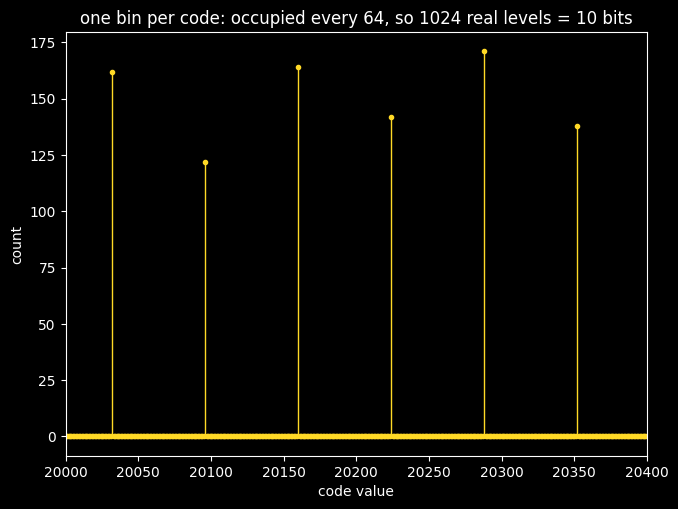

In [25]:
lo, hi = 20000, 20400
edges = np.arange(lo - 0.5, hi + 1.5)
counts, _ = np.histogram(x, edges)

fig, ax = plt.subplots()
stem(ax, np.arange(lo, hi + 1), counts)
ax.set_xlim(lo, hi); ax.set_xlabel("code value"); ax.set_ylabel("count")
ax.set_title(f"one bin per code: occupied every 64, so {nLevels} real levels = 10 bits");

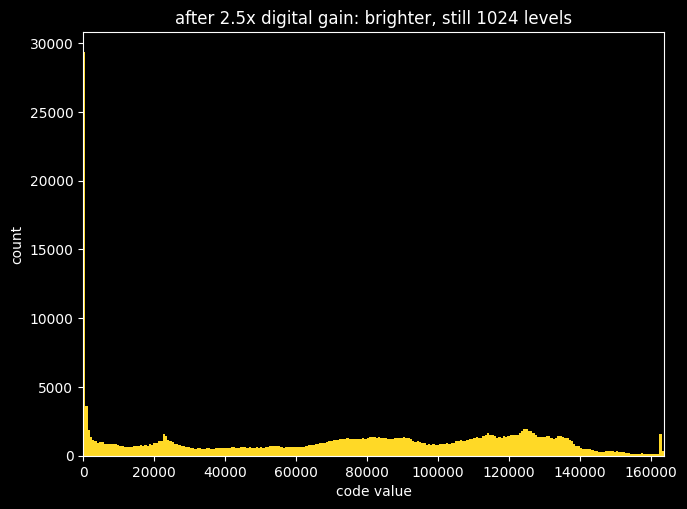

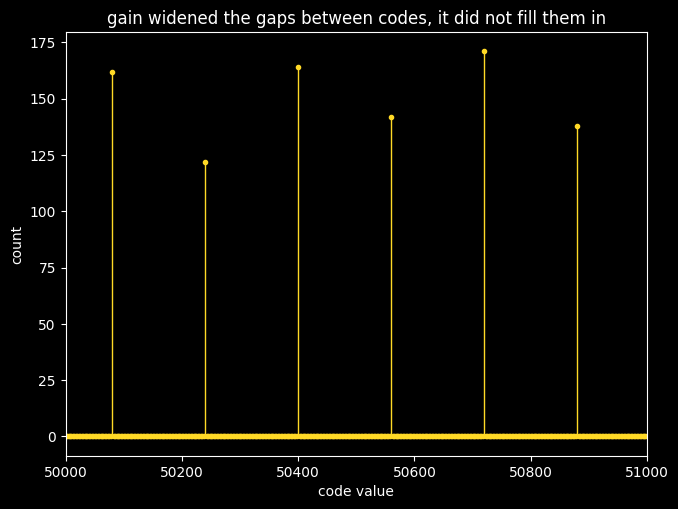

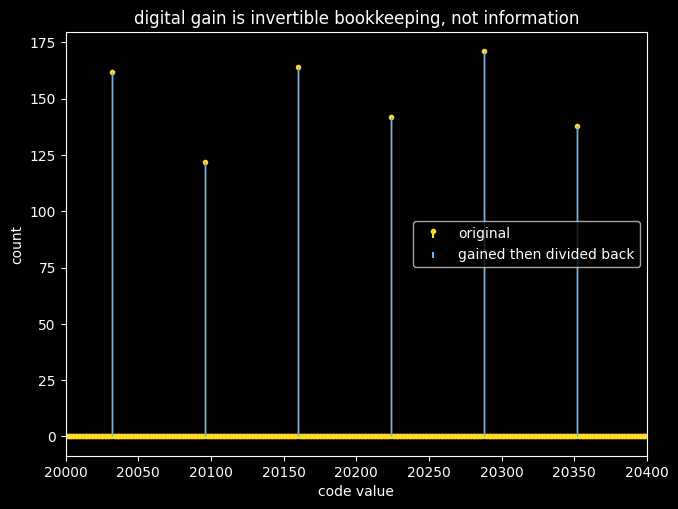

In [26]:
# digital gain: no clipping, no rounding, same number of levels
xg = x * gain
nLevelsG = np.unique(xg).size

fig, ax = plt.subplots()
ax.hist(xg, 256, color=YEL)
ax.set_xlim(0, 65535 * gain); ax.set_xlabel("code value"); ax.set_ylabel("count")
ax.set_title(f"after {gain:.1f}x digital gain: brighter, still {nLevelsG} levels")

loG, hiG = lo * gain, hi * gain
edgesG = np.arange(loG - 0.5 * gain, hiG + 0.5 * gain + 1e-9, gain)
countsG, _ = np.histogram(xg, edgesG)

fig, ax = plt.subplots()
stem(ax, edgesG[:-1] + 0.5 * gain, countsG)
ax.set_xlim(loG, hiG); ax.set_xlabel("code value"); ax.set_ylabel("count")
ax.set_title("gain widened the gaps between codes, it did not fill them in")

fig, ax = plt.subplots()
stem(ax, np.arange(lo, hi + 1), counts, label="original")
stem(ax, edgesG[:-1] / gain + 0.5, countsG, color=(0.4, 0.7, 1.0), marker=False,
     label="gained then divided back")
ax.set_xlim(lo, hi); ax.set_xlabel("code value"); ax.set_ylabel("count")
ax.legend()
ax.set_title("digital gain is invertible bookkeeping, not information");

## 6. SNR estimation: burst averaging vs one long exposure

SNR here is signal power over the power of what is left after subtracting
a noiseless reference. Calibration error counts as error, which is the
point: a bias is just as damaging as noise, and only a reference frame
reveals it. The long exposure below has a gain 3% off nominal and a
pedestal 116 counts higher than a short frame's, neither of which we
measured.

In [27]:
S = read_raw("clean_451x300_12bit_in_16.raw", 451, 300, np.uint16).astype(float)
cleanH, cleanW = S.shape

BL = 64          # black level of a short frame
sigmaRd = 60     # read noise, counts rms
nFrames = 20     # burst length
gain = 8.24      # what the long exposure actually collected
gainNom = 7      # what we asked for, and what we will assume
BLlong = 180     # its real pedestal, raised by dark current; we never measured it

rng = np.random.default_rng(0)   # fixed seed so the figures repeat in class
scene = BL + S                   # the gold standard: a noiseless short frame
sigRms = np.sqrt(np.mean(S ** 2))

def snr_db(im):
    return 20 * np.log10(sigRms / np.sqrt(np.mean((im - scene) ** 2)))

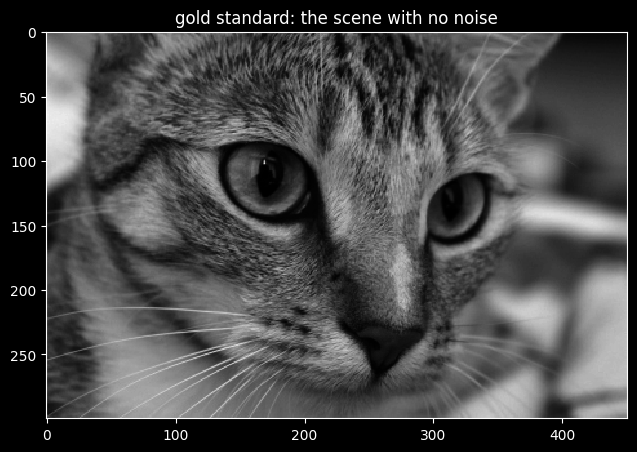

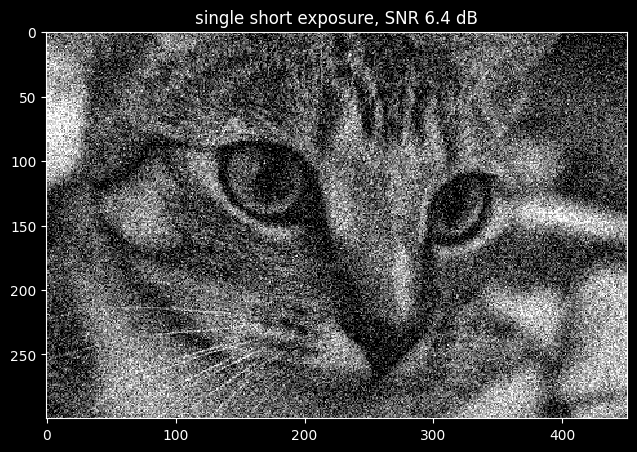

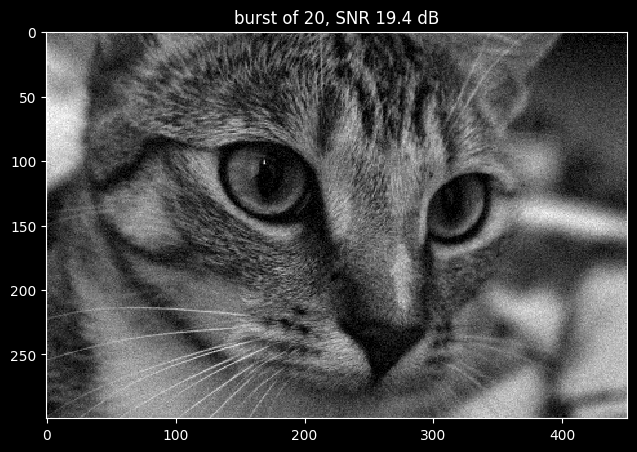

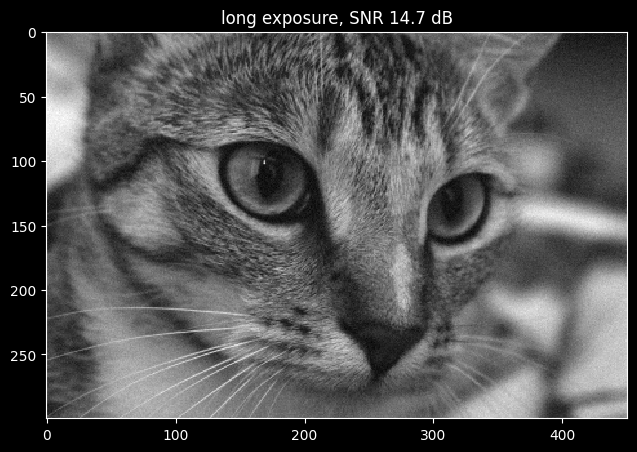

In [28]:
frame1 = scene + sigmaRd * rng.standard_normal(S.shape)

burst = np.zeros(S.shape)
for _ in range(nFrames):
    burst += scene + sigmaRd * rng.standard_normal(S.shape)
burst /= nFrames

long = BLlong + gain * S + sigmaRd * rng.standard_normal(S.shape)
longAdj = long / gainNom          # put on the short-frame scale with the numbers we think we have

for im, ttl in [(scene, "gold standard: the scene with no noise"),
                (frame1, f"single short exposure, SNR {snr_db(frame1):.1f} dB"),
                (burst, f"burst of {nFrames}, SNR {snr_db(burst):.1f} dB")]:
    fig, ax = plt.subplots()
    imagesc(ax, im, [BL, BL + 320]); ax.set_title(ttl)

fig, ax = plt.subplots()
imagesc(ax, longAdj)
ax.set_title(f"long exposure, SNR {snr_db(longAdj):.1f} dB");

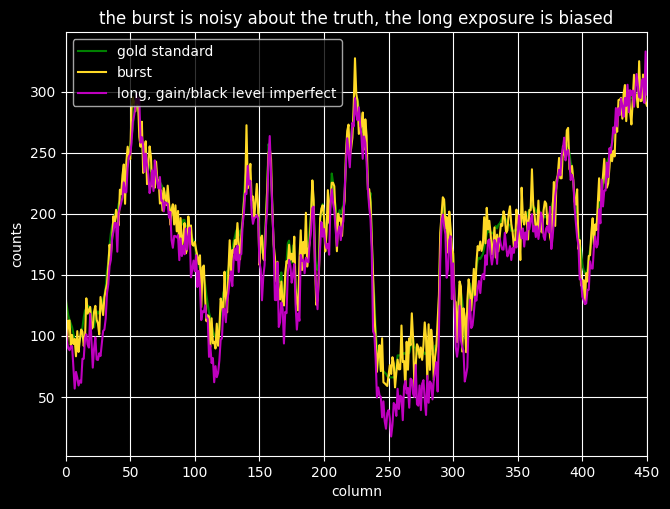

In [29]:
row = 240
fig, ax = plt.subplots()
ax.plot(scene[row, :], "g-", linewidth=1.5, label="gold standard")
ax.plot(burst[row, :], "-", color=YEL, label="burst")
ax.plot(longAdj[row, :], "m-", label="long, gain/black level imperfect")
ax.set_xlim(0, cleanW - 1)
ax.set_xlabel("column"); ax.set_ylabel("counts")
ax.legend(loc="upper left"); ax.grid(True)
ax.set_title("the burst is noisy about the truth, the long exposure is biased");